In [99]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import pickle

In [100]:
main_df = pd.read_csv("ecommerce_behavior_dataset_gpt12.csv")
main_df.head(10)

,User_ID,Name,Age,Gender,City,Product_Category,Product_Rating,Customer_Satisfaction,Frequency_of_Purchase,Purchase_Amount,Total_Orders,Returned_Orders
0,USR00001,Angela Silva,56,Other,Mumbai,Fashion,2,2.79,19,769.88,15,13
1,USR00002,Kristopher Washington,53,Other,Bangalore,Electronics,3,7.89,30,1880.20,25,5
2,USR00003,Joshua Barrett,39,Male,Delhi,Fashion,4,6.60,28,6829.41,19,2
3,USR00004,Amy Taylor,64,Other,Pune,Home Appliances,2,2.40,7,1101.46,43,19
4,USR00005,Steven Torres,42,Male,Hyderabad,Beauty,4,5.39,74,2098.34,22,4
5,USR00006,Lauren Rivers,31,Male,Mumbai,Fashion,5,6.70,4,1701.55,22,3
6,USR00007,Jeffery Wells,51,Male,Delhi,Home Appliances,5,6.31,14,1773.89,25,4
7,USR00008,Lori Santos,35,Other,Mumbai,Home Appliances,5,8.82,60,5851.56,64,0
8,USR00009,Tyler Taylor,24,Male,Pune,Home Appliances,4,5.06,17,5123.72,39,4
9,USR00010,Roger Ballard,22,Female,Delhi,Beauty,5,9.70,21,4639.88,57,36


In [101]:
main_df.columns

Index(['User_ID', 'Name', 'Age', 'Gender', 'City', 'Product_Category',
       'Product_Rating', 'Customer_Satisfaction', 'Frequency_of_Purchase',
       'Purchase_Amount', 'Total_Orders', 'Returned_Orders'],
      dtype='object')

In [102]:
df = main_df

In [103]:
df.isnull().sum()

User_ID                  0
Name                     0
Age                      0
Gender                   0
City                     0
Product_Category         0
Product_Rating           0
Customer_Satisfaction    0
Frequency_of_Purchase    0
Purchase_Amount          0
Total_Orders             0
Returned_Orders          0
dtype: int64

In [104]:
df.shape[0]

15000

In [105]:
df.dtypes


User_ID                   object
Name                      object
Age                        int64
Gender                    object
City                      object
Product_Category          object
Product_Rating             int64
Customer_Satisfaction    float64
Frequency_of_Purchase      int64
Purchase_Amount          float64
Total_Orders               int64
Returned_Orders            int64
dtype: object

In [106]:
df.dtypes

User_ID                   object
Name                      object
Age                        int64
Gender                    object
City                      object
Product_Category          object
Product_Rating             int64
Customer_Satisfaction    float64
Frequency_of_Purchase      int64
Purchase_Amount          float64
Total_Orders               int64
Returned_Orders            int64
dtype: object

In [107]:
df['Return_Rate'] = (df['Returned_Orders']/df['Total_Orders'])

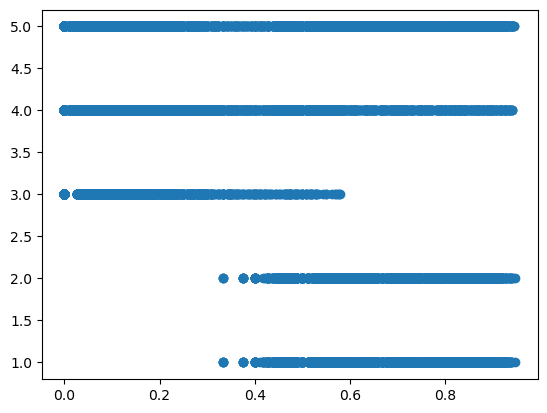

In [108]:
plt.scatter(
    df['Return_Rate'], 
    df['Product_Rating'],
   
)

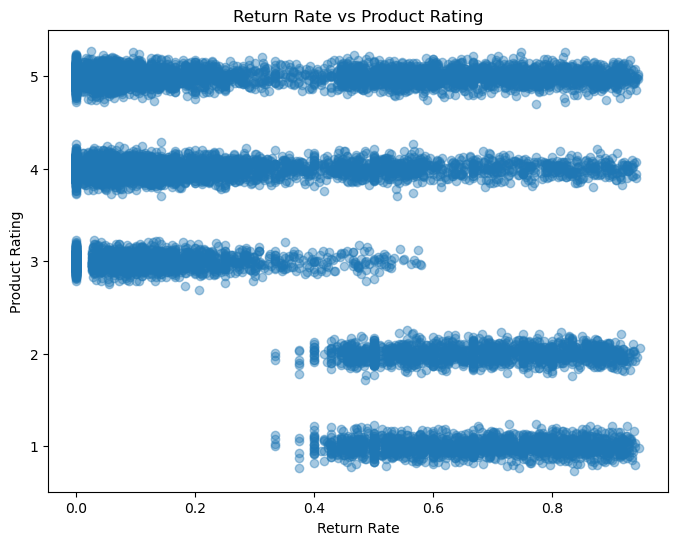

In [109]:


x = df["Return_Rate"]

y = df["Product_Rating"] + np.random.normal(0, 0.08, len(df))

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.4)

plt.xlabel("Return Rate")
plt.ylabel("Product Rating")
plt.title("Return Rate vs Product Rating")

plt.show()

In [110]:
df.head()

,User_ID,Name,Age,Gender,City,Product_Category,Product_Rating,Customer_Satisfaction,Frequency_of_Purchase,Purchase_Amount,Total_Orders,Returned_Orders,Return_Rate
0,USR00001,Angela Silva,56,Other,Mumbai,Fashion,2,2.79,19,769.88,15,13,0.866667
1,USR00002,Kristopher Washington,53,Other,Bangalore,Electronics,3,7.89,30,1880.20,25,5,0.200000
2,USR00003,Joshua Barrett,39,Male,Delhi,Fashion,4,6.60,28,6829.41,19,2,0.105263
3,USR00004,Amy Taylor,64,Other,Pune,Home Appliances,2,2.40,7,1101.46,43,19,0.441860
4,USR00005,Steven Torres,42,Male,Hyderabad,Beauty,4,5.39,74,2098.34,22,4,0.181818


In [111]:
df.loc[df["Purchase_Amount"] > 1000 , "Purchase_Amount"] /= 10

In [112]:
df["value_per_visit"] = df["Purchase_Amount"]/(df["Frequency_of_Purchase"]+1)
df["return_ratio"] = df["Return_Rate"]/(df["Frequency_of_Purchase"]+2)


In [113]:
df["return_ratio"] = df["return_ratio"].clip(0, 1)

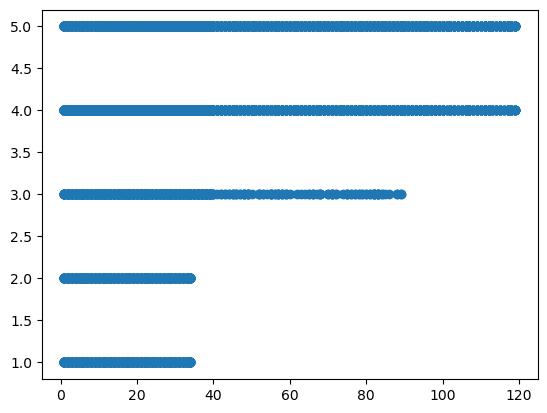

In [114]:
plt.scatter(
    df['Frequency_of_Purchase'], 
    df['Product_Rating'],
   
)

In [115]:

df["Product_Rating"] = df["Product_Rating"].round().astype(int).clip(0,5)

In [116]:
df.dtypes

User_ID                   object
Name                      object
Age                        int64
Gender                    object
City                      object
Product_Category          object
Product_Rating             int32
Customer_Satisfaction    float64
Frequency_of_Purchase      int64
Purchase_Amount          float64
Total_Orders               int64
Returned_Orders            int64
Return_Rate              float64
value_per_visit          float64
return_ratio             float64
dtype: object

In [117]:
features = df[["Product_Rating","Frequency_of_Purchase",
               "Customer_Satisfaction","value_per_visit","return_ratio"]]

In [118]:
scaler = StandardScaler()

In [119]:
scaled_features = scaler.fit_transform(features)

In [120]:
model = IsolationForest(contamination=0.08,n_estimators=250, max_samples='auto')

In [121]:
model.fit(scaled_features)

IsolationForest(contamination=0.08, n_estimators=250)

In [122]:
df["anomaly"] = model.predict(scaled_features)
df.head()

,User_ID,Name,Age,Gender,City,Product_Category,Product_Rating,Customer_Satisfaction,Frequency_of_Purchase,Purchase_Amount,Total_Orders,Returned_Orders,Return_Rate,value_per_visit,return_ratio,anomaly
0,USR00001,Angela Silva,56,Other,Mumbai,Fashion,2,2.79,19,769.880,15,13,0.866667,38.494000,0.041270,1
1,USR00002,Kristopher Washington,53,Other,Bangalore,Electronics,3,7.89,30,188.020,25,5,0.200000,6.065161,0.006250,1
2,USR00003,Joshua Barrett,39,Male,Delhi,Fashion,4,6.60,28,682.941,19,2,0.105263,23.549690,0.003509,1
3,USR00004,Amy Taylor,64,Other,Pune,Home Appliances,2,2.40,7,110.146,43,19,0.441860,13.768250,0.049096,1
4,USR00005,Steven Torres,42,Male,Hyderabad,Beauty,4,5.39,74,209.834,22,4,0.181818,2.797787,0.002392,1


In [123]:
df.loc[
    (df["Product_Rating"] <= 2) &
    (df["Customer_Satisfaction"] <= 4) &
    (df["Return_Rate"] >= 0.75),
    "anomaly"
] = 1

anomaly
 1    14133
-1      867
Name: count, dtype: int64

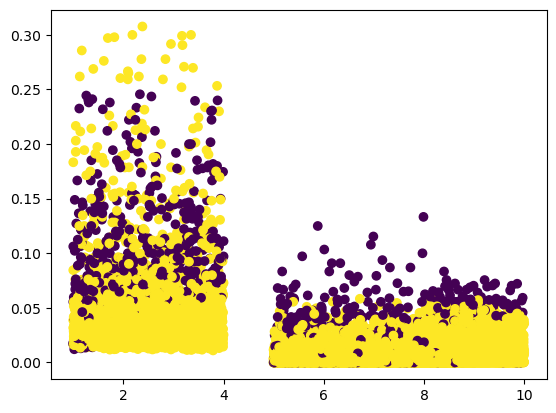

In [124]:
plt.scatter(
    df['Customer_Satisfaction'], 
    df['return_ratio'],
    c=df["anomaly"]
)

df['anomaly'].value_counts()


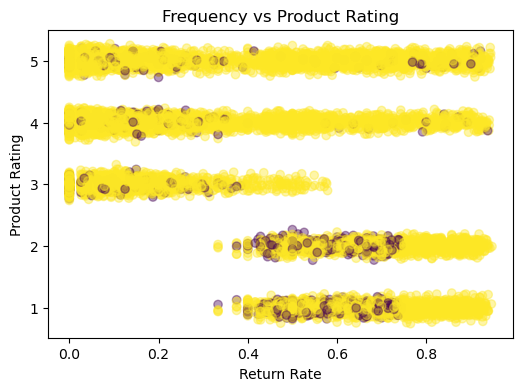

In [125]:
x = df["Return_Rate"]

y = (
    df["Product_Rating"]
    + np.random.normal(0, 0.08, len(df))
)

plt.figure(figsize=(6,4))

plt.scatter(
    x,
    y,
    c = df["anomaly"],
    alpha=0.4
)

plt.xlabel("Return Rate")
plt.ylabel("Product Rating")
plt.title("Frequency vs Product Rating")

plt.show()

In [126]:
scores = model.decision_function(scaled_features)
df['anomaly_score'] = scores

In [127]:
df[["anomaly","anomaly_score"]].sort_values(by = "anomaly_score")

,anomaly,anomaly_score
4644,1,-0.204745
10960,1,-0.203600
9906,-1,-0.198949
8593,1,-0.197240
2237,1,-0.196342
...,...,...
1201,1,0.158414
9141,1,0.158658
4576,1,0.158742
13477,1,0.159682


In [128]:
df.head(2)

,User_ID,Name,Age,Gender,City,Product_Category,Product_Rating,Customer_Satisfaction,Frequency_of_Purchase,Purchase_Amount,Total_Orders,Returned_Orders,Return_Rate,value_per_visit,return_ratio,anomaly,anomaly_score
0,USR00001,Angela Silva,56,Other,Mumbai,Fashion,2,2.79,19,769.88,15,13,0.866667,38.494000,0.04127,1,0.048532
1,USR00002,Kristopher Washington,53,Other,Bangalore,Electronics,3,7.89,30,188.02,25,5,0.200000,6.065161,0.00625,1,0.100749


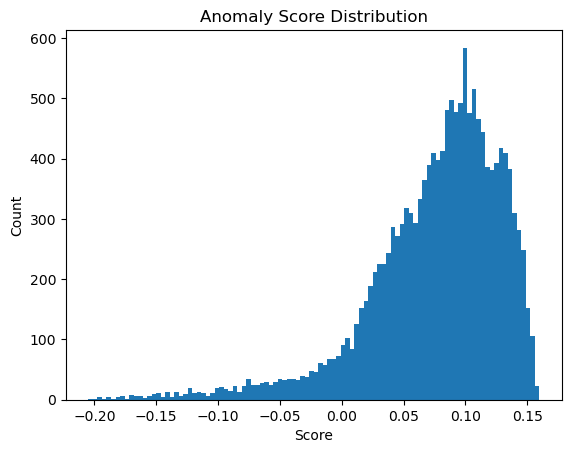

In [129]:
plt.hist(df['anomaly_score'], bins=100)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

In [130]:
scoring_features = ["Product_Rating","Frequency_of_Purchase",
               "Customer_Satisfaction","value_per_visit","return_ratio"]

In [131]:
score_scaler = MinMaxScaler()
df[scoring_features] = score_scaler.fit_transform(df[scoring_features])

In [132]:
df["Trust_Score"] = (
    0.35*df["Customer_Satisfaction"]+
    0.25*df["Product_Rating"]+
    0.20*df["Frequency_of_Purchase"]-
    0.35*(1-df["return_ratio"])-
    0.3*(1-df["value_per_visit"])

)

In [133]:
df.loc[df["anomaly"] == -1,"Trust_Score"] /= 6
df["Trust_Score"] = df["Trust_Score"] + df["anomaly_score"]

In [134]:
df["Trust_Score"] = (df["Trust_Score"] - df["Trust_Score"].min()) / (df["Trust_Score"].max() - df["Trust_Score"].min())
df["Trust_Score"] = df["Trust_Score"]*100

In [135]:
def label(score):
    if score > 60:
        return "High Trust"
    elif score > 35:
        return "Medium Trust"
    else:
        return "Low Trust"

df["Trust_Label"] = df["Trust_Score"].apply(label)

In [136]:
df["Trust_Label"].value_counts()

Trust_Label
High Trust      10992
Low Trust        2525
Medium Trust     1483
Name: count, dtype: int64

In [137]:
pickle.dump(scaler, open("scaler11.pkl","wb"))

In [138]:
filename = "IsolationModel11"
pickle.dump(model,open(filename,"wb"))

In [139]:
pickle.dump(score_scaler,open("score_scaler11.pkl","wb"))